In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = pd.read_csv("C:\\Users\\USER\\Desktop\\Data analysis\\ML project\\images\\icml_face_data.csv")
data = data.rename(columns={" pixels": "pixels", " Usage": "usage"})

In [5]:
data.head()

,emotion,usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [7]:
train_data = data.loc[data['usage'] == 'Training'].drop('usage', axis=1).reset_index(drop=True)
validation_data = data.loc[data['usage'] == 'PublicTest'].drop('usage', axis=1).reset_index(drop=True)
test_data = data.loc[data['usage'] == 'PrivateTest'].drop('usage', axis=1).reset_index(drop=True)

In [9]:
train_data.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [11]:
validation_data.head()

,emotion,pixels
0,0,254 254 254 254 254 249 255 160 2 58 53 70 77 ...
1,1,156 184 198 202 204 207 210 212 213 214 215 21...
2,4,69 118 61 60 96 121 103 87 103 88 70 90 115 12...
3,6,205 203 236 157 83 158 120 116 94 86 155 180 2...
4,3,87 79 74 66 74 96 77 80 80 84 83 89 102 91 84 ...


In [13]:
test_data.head()

,emotion,pixels
0,0,170 118 101 88 88 75 78 82 66 74 68 59 63 64 6...
1,5,7 5 8 6 7 3 2 6 5 4 4 5 7 5 5 5 6 7 7 7 10 10 ...
2,6,232 240 241 239 237 235 246 117 24 24 22 13 12...
3,4,200 197 149 139 156 89 111 58 62 95 113 117 11...
4,2,40 28 33 56 45 33 31 78 152 194 200 186 196 20...


(array([4953.,  547.,    0., 5121.,    0., 8989., 6077.,    0., 4002.,
        6198.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

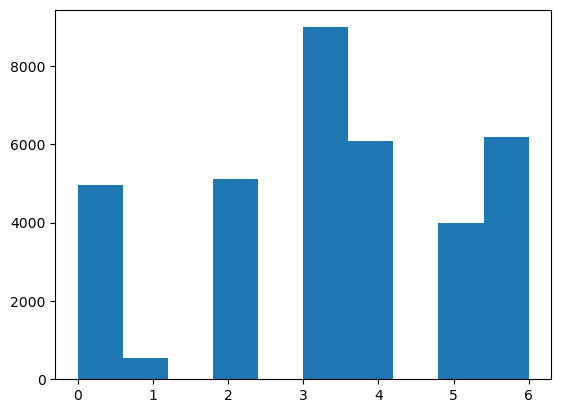

In [21]:
plt.hist(data['emotion'])

In [23]:
n = 48  # Image size (48x48)
emotion_dict = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

In [25]:
train_data["image"] = train_data["pixels"].map(lambda x: np.array([int(i) for i in x.split()]) / 255.0)
validation_data["image"] = validation_data["pixels"].map(lambda x: np.array([int(i) for i in x.split()]) / 255.0)
test_data["image"] = test_data["pixels"].map(lambda x: np.array([int(i) for i in x.split()]) / 255.0)

In [26]:
X_train = np.stack(train_data['image'])
y_train = train_data['emotion']

In [27]:
X_validation = np.stack(validation_data['image'])
y_validation = validation_data['emotion']

In [28]:
X_test = np.stack(test_data['image'])
y_test = test_data['emotion']

In [29]:
# Flatten images for Logistic Regression
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_validation_flattened = X_validation.reshape(X_validation.shape[0], -1)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)

In [40]:
model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
model.fit(X_train_flattened, y_train)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [41]:
# Evaluate the model
y_validation_pred = model.predict(X_validation_flattened)
validation_accuracy = accuracy_score(y_validation, y_validation_pred)
print(f"Validation Accuracy: {validation_accuracy * 100:.2f}%")

Validation Accuracy: 35.25%


In [42]:
# Test the model
y_test_pred = model.predict(X_test_flattened)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 35.80%


In [43]:
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, target_names=list(emotion_dict.values())))



Classification Report:
               precision    recall  f1-score   support

       Angry       0.25      0.20      0.22       491
     Disgust       0.17      0.07      0.10        55
        Fear       0.25      0.18      0.21       528
       Happy       0.46      0.60      0.52       879
         Sad       0.28      0.29      0.28       594
    Surprise       0.49      0.48      0.49       416
     Neutral       0.31      0.30      0.31       626

    accuracy                           0.36      3589
   macro avg       0.32      0.30      0.30      3589
weighted avg       0.34      0.36      0.35      3589



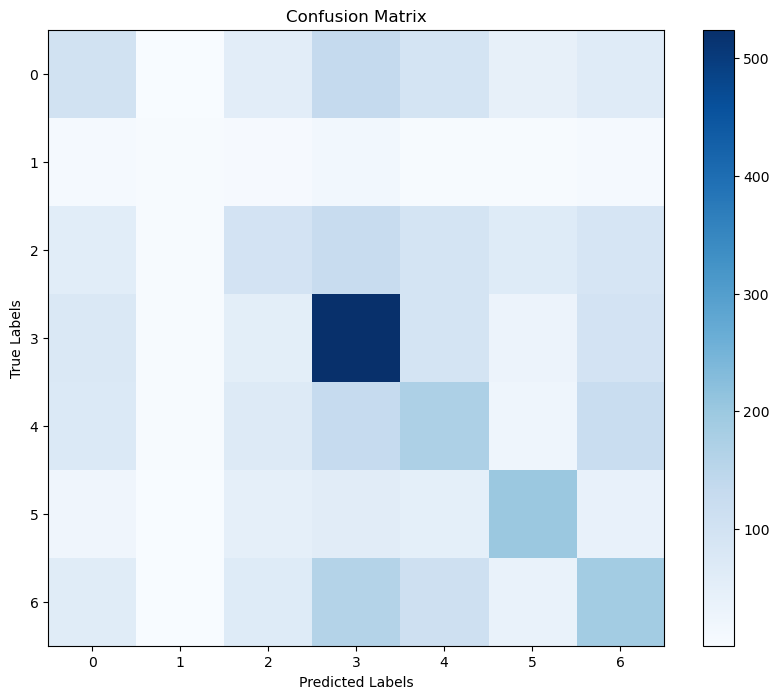

In [44]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.colorbar()
plt.show()

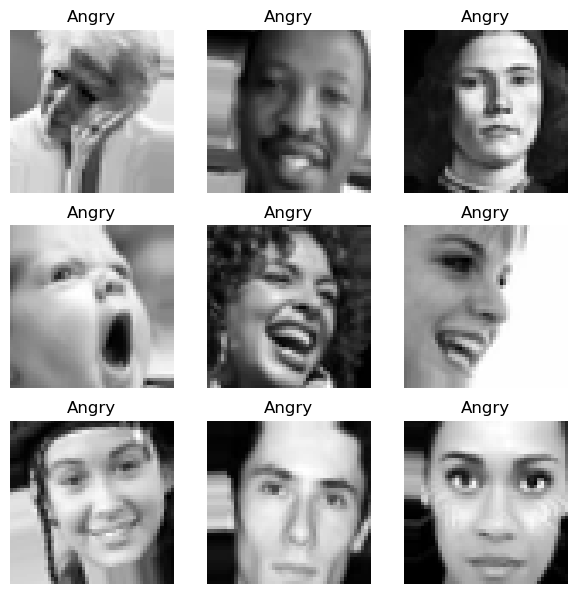

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# Define the data augmentation
data_gen = ImageDataGenerator(
    rotation_range=15,        # Rotate images randomly by up to 15 degrees
    width_shift_range=0.1,    # Random horizontal shift
    height_shift_range=0.1,   # Random vertical shift
    zoom_range=0.1,           # Random zoom
    horizontal_flip=True,     # Randomly flip images horizontally
)

# Reshape X_train to add the channel dimension for compatibility with ImageDataGenerator
X_train_aug = X_train.reshape(-1, n, n, 1)

# Create the generator
train_generator = data_gen.flow(X_train_aug, y_train, batch_size=32)

# Fetch a batch of augmented images and labels
augmented_images, augmented_emotions = next(train_generator)

# Plot augmented images
px = 1 / plt.rcParams['figure.dpi']
rows, columns = 3, 3  # Display 3x3 grid of augmented images
fig = plt.figure(figsize=(720 * px, 720 * px))
for i in range(rows * columns):
    fig.add_subplot(rows, columns, i + 1)
    plt.imshow(augmented_images[i].reshape(n, n), cmap='gray')  # Reshape to 2D for grayscale display
    plt.axis('off')
    plt.title(emotion_dict.get(np.argmax(augmented_emotions[i])))
plt.show()


Epoch 1/20


C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1361 - loss: 2.1165 - val_accuracy: 0.1200 - val_loss: 2.0804
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2311 - loss: 1.9358 - val_accuracy: 0.1450 - val_loss: 2.1976
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2342 - loss: 1.8610 - val_accuracy: 0.1400 - val_loss: 2.1188
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3316 - loss: 1.7132 - val_accuracy: 0.1650 - val_loss: 2.0742
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4356 - loss: 1.6112 - val_accuracy: 0.0950 - val_loss: 2.1178
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4731 - loss: 1.5352 - val_accuracy: 0.1500 - val_loss: 2.0911
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4843 - loss: 1.4708 - val_accuracy: 0.1500 - val_loss: 2.1184
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5712 - loss: 1.3853 - val_accuracy: 0.1750 - val_loss: 2.0436
Ep

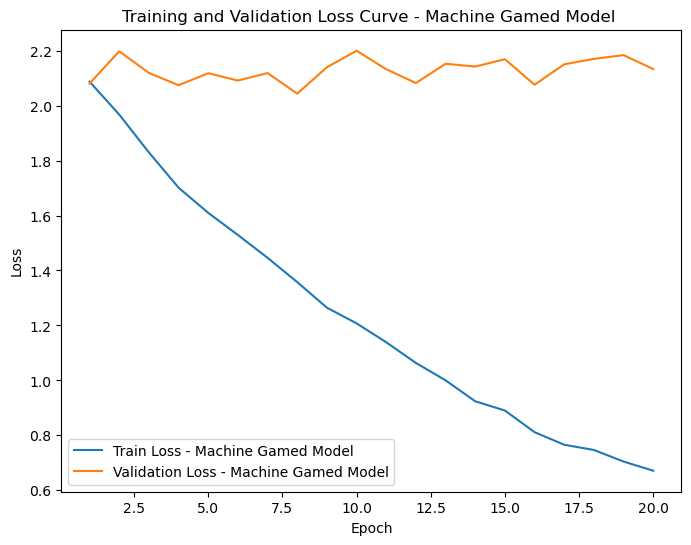

In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Example data preparation
# Simulate grayscale images (48x48) and corresponding labels (7 classes)
np.random.seed(42)
X = np.random.rand(1000, 48, 48)
y = np.random.randint(0, 7, 1000)

# Preprocess data: Flatten images and one-hot encode labels
X = X.reshape(-1, 48, 48, 1)  # Add channel dimension for compatibility
y_onehot = to_categorical(y, num_classes=7)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Model 1: Logistic Regression-like Model
model_1 = Sequential([
    Flatten(input_shape=(48, 48, 1)),  # Flatten the input
    Dense(7, activation='softmax')    # Output layer for 7 classes
])

# Compile the model
model_1.compile(optimizer=Adam(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Train the model and capture the history
history_1 = model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, batch_size=32,
    verbose=1
)

# Model 2: Logistic Regression with a Hidden Layer
#model_2 = Sequential([
#    Flatten(input_shape=(48, 48, 1)),  # Flatten the input
#    Dense(128, activation='relu'),    # Hidden layer
#    Dense(7, activation='softmax')    # Output layer for 7 classes
#])

# Compile the second model
#model_2.compile(optimizer=Adam(learning_rate=0.0005),  # Lower learning rate
#                loss='categorical_crossentropy',
#                metrics=['accuracy'])

# Train the second model and capture the history
#history_2 = model_2.fit(
#    X_train, y_train,
#    validation_data=(X_val, y_val),
#    epochs=20, batch_size=32,
#    verbose=1
#)

# Convert training histories to DataFrames for visualization
train_history_1 = pd.DataFrame(history_1.history)
train_history_1['epoch'] = range(1, len(train_history_1['loss']) + 1)

#train_history_2 = pd.DataFrame(history_2.history)
#train_history_2['epoch'] = range(1, len(train_history_2['loss']) + 1)

# Plot the training and validation loss for Model 1
plt.figure(figsize=(8, 6))
sns.lineplot(x='epoch', y='loss', data=train_history_1, label='Train Loss - Machine Gamed Model')
sns.lineplot(x='epoch', y='val_loss', data=train_history_1, label='Validation Loss - Machine Gamed Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve - Machine Gamed Model ')
plt.legend()
plt.show()

# Plot the training and validation loss for Model 2
#plt.figure(figsize=(8, 6))
#sns.lineplot(x='epoch', y='loss', data=train_history_2, label='Train Loss - Model 2')
#sns.lineplot(x='epoch', y='val_loss', data=train_history_2, label='Validation Loss - Model 2')
#plt.xlabel('Epoch')
#plt.ylabel('Loss')
#plt.title('Training and Validation Loss Curve - Model 2')
#plt.legend()
#plt.show()


In [ ]:

test_loss_1, test_accuracy_1 = model_1.evaluate(X_val, y_val, verbose=1)


test_loss_2, test_accuracy_2 = model_2.evaluate(X_val, y_val, verbose=1)

print(f"Model 1 - Accuracy on Validation Data: {test_accuracy_1 * 100:.2f}%")
print(f"Model 2 - Accuracy on Validation Data: {test_accuracy_2 * 100:.2f}%")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1472 - loss: 2.1268 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1207 - loss: 2.2331 
Model 1 - Accuracy on Validation Data: 16.00%
Model 2 - Accuracy on Validation Data: 11.00%


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


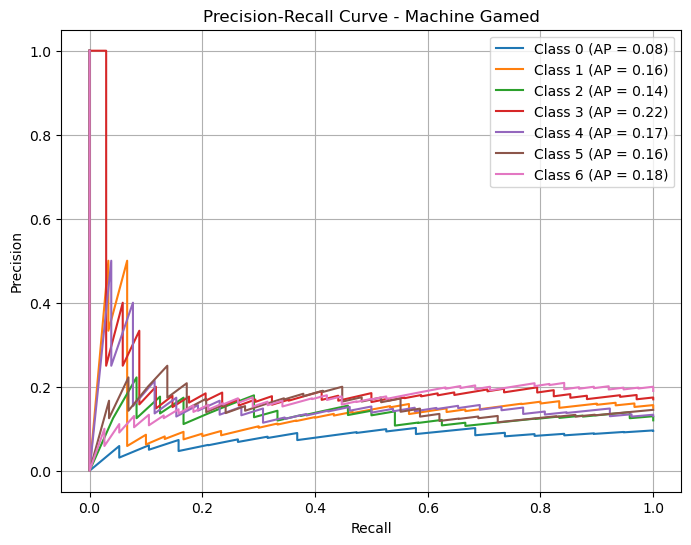

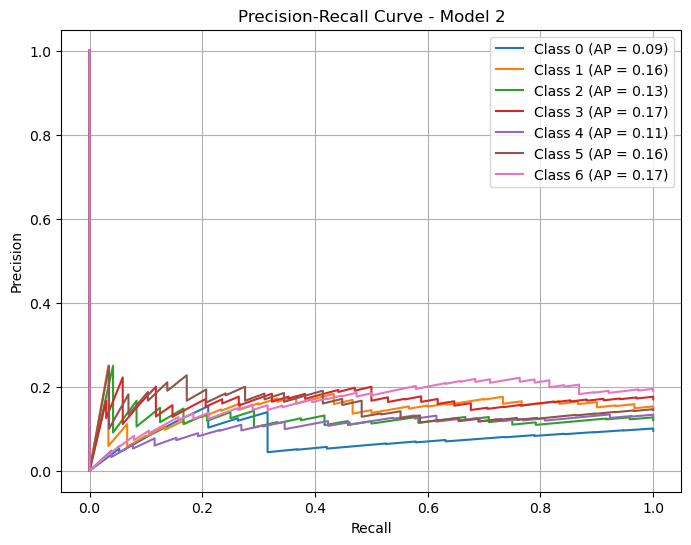

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer

# Get the model predictions (probabilities)
y_pred_1 = model_1.predict(X_val)  # Predictions for Model 1
y_pred_2 = model_2.predict(X_val)  # Predictions for Model 2

# Binarize the labels for multi-class classification
lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val)

# Function to plot Precision-Recall curve for each class
def plot_precision_recall_curve(y_true, y_pred, num_classes, model_name):
    plt.figure(figsize=(8, 6))
    
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred[:, i])
        average_precision = average_precision_score(y_true[:, i], y_pred[:, i])
        
        # Plot the Precision-Recall curve for the current class
        plt.plot(recall, precision, label=f'Class {i} (AP = {average_precision:.2f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Plot Precision-Recall curve for Model 1
plot_precision_recall_curve(y_val_bin, y_pred_1, num_classes=7, model_name='Machine Gamed')

# Plot Precision-Recall curve for Model 2
plot_precision_recall_curve(y_val_bin, y_pred_2, num_classes=7, model_name='Model 2')


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


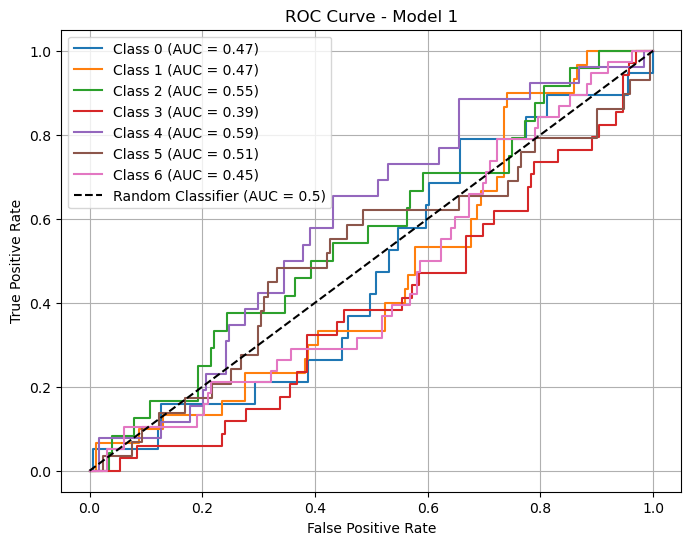

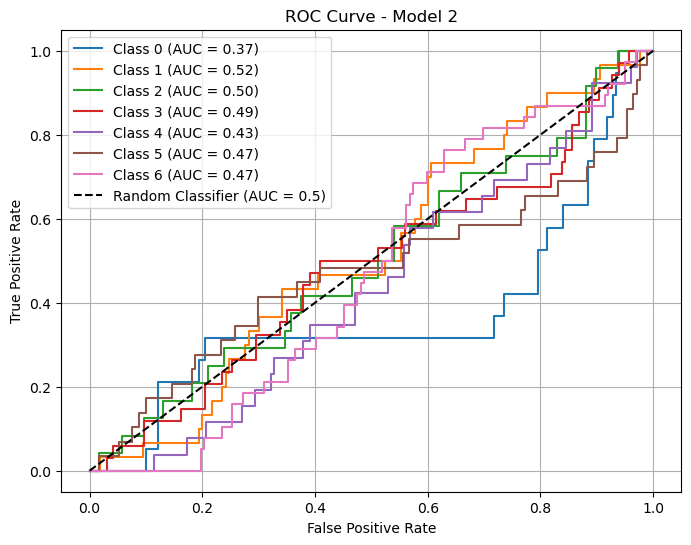

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Predict probabilities for the validation set
y_pred_proba_1 = model.predict(X_val)  # Probabilities for Model 1
y_pred_proba_2 = model_2.predict(X_val)  # Probabilities for Model 2, if you have Model 2

# Binarize the true labels (multi-class classification)
lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val)

# Function to plot ROC curve and compute AUC for each class
def plot_roc_curve(y_true, y_pred_proba, num_classes, model_name):
    plt.figure(figsize=(8, 6))
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    # Compute ROC curve and AUC for each class
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Plot the ROC curve for each class
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    
    # Plot ROC curve for random classifier
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

    # Set plot labels and title
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Plot ROC curve and AUC for Model 1
plot_roc_curve(y_val_bin, y_pred_proba_1, num_classes=7, model_name='Model 1')

# Plot ROC curve and AUC for Model 2 (if you have a second model)
plot_roc_curve(y_val_bin, y_pred_proba_2, num_classes=7, model_name='Model 2')


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


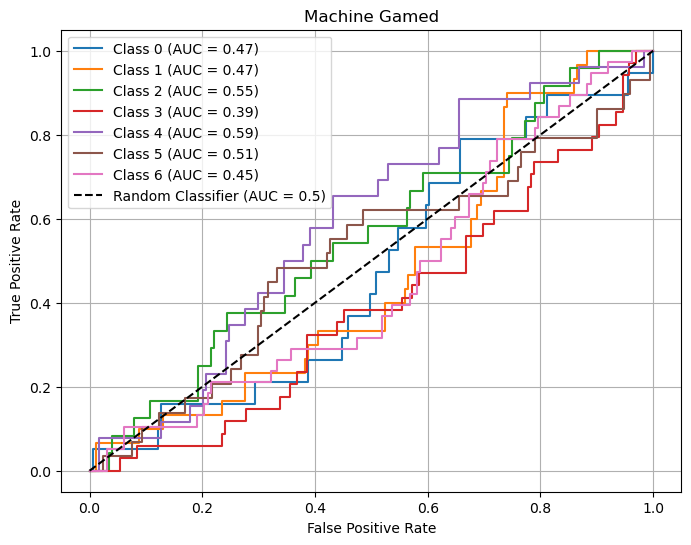

In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Predict probabilities for the validation set using Model 1
y_pred_proba_1 = model.predict(X_val)  # Probabilities for Model 1

# Binarize the true labels (multi-class classification)
lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val)

# Function to plot ROC curve and compute AUC for each class
def plot_roc_curve(y_true, y_pred_proba, num_classes, model_name):
    plt.figure(figsize=(8, 6))
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    # Compute ROC curve and AUC for each class
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Plot the ROC curve for each class
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    
    # Plot ROC curve for random classifier
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

    # Set plot labels and title
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("Machine Gamed")
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Plot ROC curve and AUC for Model 1
plot_roc_curve(y_val_bin, y_pred_proba_1, num_classes=7, model_name='Machine Gamed')
